# Notebook 04 - Model Development
## Fake News Detection - NLP Assignment
### Person 2: W.A. Irusha Madushan (CIT-24-01-0514)
### Models: Random Forest (ML) + CNN (Deep Learning)

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# TensorFlow - CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
TensorFlow version: 2.21.0


## 1. Loading Saved Features

The TF-IDF features and CNN padded sequences that were prepared 
in Notebook 03 are loaded here. This avoids repeating the 
feature engineering process and ensures both models are trained 
on exactly the same train/test split.

In [2]:
# Load TF-IDF features
X_train_tfidf = sp.load_npz('../models/X_train_tfidf.npz')
X_test_tfidf = sp.load_npz('../models/X_test_tfidf.npz')

# Load CNN padded sequences
X_train_pad = np.load('../models/X_train_pad.npy')
X_test_pad = np.load('../models/X_test_pad.npy')

# Load labels
y_train = np.load('../models/y_train.npy')
y_test = np.load('../models/y_test.npy')

print("All features loaded successfully")
print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)
print("CNN Train shape:", X_train_pad.shape)
print("CNN Test shape:", X_test_pad.shape)
print("Train labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

All features loaded successfully
TF-IDF Train shape: (57632, 50000)
TF-IDF Test shape: (14409, 50000)
CNN Train shape: (57632, 300)
CNN Test shape: (14409, 300)
Train labels shape: (57632,)
Test labels shape: (14409,)


## 2. Random Forest Model

Random Forest is an ensemble machine learning method that builds 
multiple decision trees during training and combines their results 
to make a final prediction. It works well with high dimensional 
data like TF-IDF features because it can handle a large number 
of input features and select the most important ones automatically.

I will first train a baseline model, then experiment with 
different hyperparameters to find the best settings.

In [3]:
# Baseline Random Forest model
print("Training baseline Random Forest model...")
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_tfidf, y_train)

# accuracy check
baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test_tfidf))
print("Baseline Random Forest Training Complete")
print("Baseline Accuracy:", round(baseline_acc * 100, 2), "%")

Training baseline Random Forest model...
Baseline Random Forest Training Complete
Baseline Accuracy: 95.21 %


## 3. Random Forest Hyperparameter Tuning

To improve the baseline model, I experimented with different 
numbers of trees (n_estimators) and maximum tree depth (max_depth). 
Comparing these settings helps find the best combination for 
fake news detection.

In [4]:
# checking with different hyperparameters
results = []

settings = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': 50},
    {'n_estimators': 200, 'max_depth': 50},
]

for setting in settings:
    print(f"Training RF with n_estimators={setting['n_estimators']}, max_depth={setting['max_depth']}...")
    rf = RandomForestClassifier(
        n_estimators=setting['n_estimators'],
        max_depth=setting['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test_tfidf))
    results.append({
        'n_estimators': setting['n_estimators'],
        'max_depth': setting['max_depth'],
        'accuracy': round(acc * 100, 2)
    })
    print(f"Accuracy: {round(acc * 100, 2)}%")

# Show results
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)

Training RF with n_estimators=100, max_depth=None...
Accuracy: 95.21%
Training RF with n_estimators=200, max_depth=None...
Accuracy: 95.53%
Training RF with n_estimators=100, max_depth=50...
Accuracy: 94.82%
Training RF with n_estimators=200, max_depth=50...
Accuracy: 95.0%

Hyperparameter Tuning Results:
   n_estimators  max_depth  accuracy
0           100        NaN     95.21
1           200        NaN     95.53
2           100       50.0     94.82
3           200       50.0     95.00


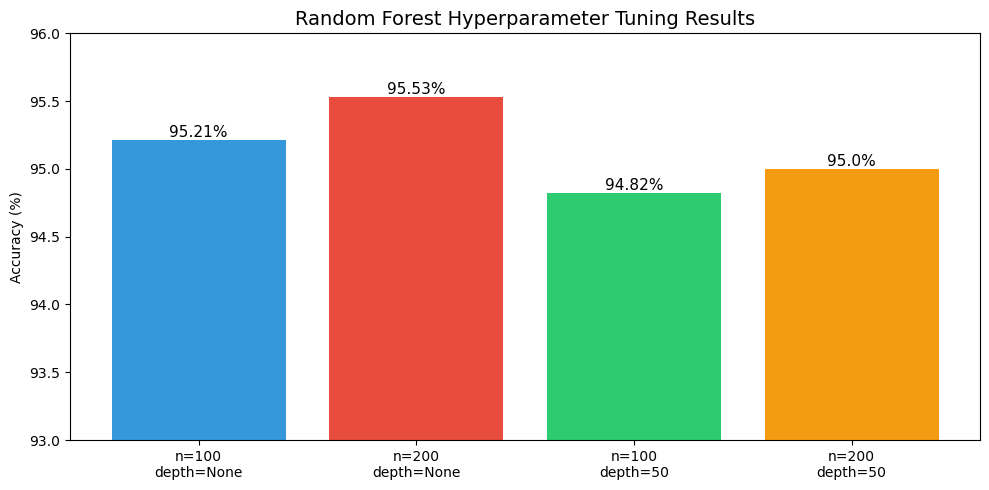

In [5]:
# Generate a chart comparing the hyperparameter evaluation scores
plt.figure(figsize=(10, 5))
labels = [f"n={r['n_estimators']}\ndepth={r['max_depth']}" 
          for r in results]
accuracies = [r['accuracy'] for r in results]

bars = plt.bar(labels, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Random Forest Hyperparameter Tuning Results', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(93, 96)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{acc}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/rf_tuning_results.png', dpi=150)
plt.show()

### Insight - Hyperparameter Tuning Results

From the four experiments the best result was achieved with 
200 trees and no maximum depth limit (95.53% accuracy) 

Increasing the number of trees from 100 to 200 improved 
accuracy slightly because more trees reduce variance in 
the predictions. Setting a maximum depth of 50 actually 
reduced accuracy because it prevented trees from fully 
learning the patterns in the data.

Therefore the final Random Forest model will use 
n_estimators=200 and max_depth=None.

In [6]:
# Train final best Random Forest model
print("Training final Random Forest model...")

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_tfidf, y_train)

# Save model
with open('../models/rf_final_model.pkl', 'wb') as f:
    pickle.dump(rf_final, f)

print("Final Random Forest model trained and saved successfully")
print("Final Accuracy:", round(accuracy_score(y_test, rf_final.predict(X_test_tfidf)) * 100, 2), "%")

Training final Random Forest model...
Final Random Forest model trained and saved successfully
Final Accuracy: 95.53 %


## 4. CNN Model (Convolutional Neural Network)

CNN is a deep learning model that was originally designed for 
image processing but works very well for text classification too. 
For text, the CNN learns to detect important word patterns and 
combinations across the article sequences.

The architecture I used is:
- Embedding layer: converts word numbers into dense vectors
- Conv1D layer: detects local word patterns across the sequence
- GlobalMaxPooling1D: picks the most important feature from each filter
- Dense layers: makes the final fake or real prediction

I will experiment with different filter sizes and dropout rates 
to find the best CNN configuration.

In [7]:
# CNN Model parameters
MAX_WORDS = 50000
MAX_LEN = 300
EMBEDDING_DIM = 100

# Build baseline CNN
def build_cnn(filters=128, kernel_size=5, dropout_rate=0.5):
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, 
                  output_dim=EMBEDDING_DIM, 
                  input_length=MAX_LEN),
        Conv1D(filters=filters, 
               kernel_size=kernel_size, 
               activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train baseline CNN
print("Training baseline CNN model...")
cnn_baseline = build_cnn(filters=128, kernel_size=5, dropout_rate=0.5)
cnn_baseline.summary()

Training baseline CNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# To prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', 
                            patience=2, 
                            restore_best_weights=True)

# Train baseline CNN
history_baseline = cnn_baseline.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

baseline_cnn_acc = cnn_baseline.evaluate(X_test_pad, y_test, verbose=0)[1]
print("\nBaseline CNN Test Accuracy:", round(baseline_cnn_acc * 100, 2), "%")

Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 93s 108ms/step - accuracy: 0.9337 - loss: 0.1635 - val_accuracy: 0.9679 - val_loss: 0.0881
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 108s 133ms/step - accuracy: 0.9896 - loss: 0.0342 - val_accuracy: 0.9774 - val_loss: 0.0732
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 88s 109ms/step - accuracy: 0.9986 - loss: 0.0057 - val_accuracy: 0.9764 - val_loss: 0.0917
Epoch 4/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 89s 110ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9748 - val_loss: 0.1329

Baseline CNN Test Accuracy: 97.42 %


## 5. CNN Hyperparameter Experiments

To find the best CNN configuration I experimented with different 
filter sizes and dropout rates. Filter size controls how many 
words the CNN looks at together at once. Dropout rate controls 
how much the model regularizes itself to prevent overfitting.

In [9]:
# CNN Hyperparameter experiments
cnn_results = []

settings = [
    {'filters': 128, 'kernel_size': 5, 'dropout': 0.5},
    {'filters': 256, 'kernel_size': 5, 'dropout': 0.5},
    {'filters': 128, 'kernel_size': 3, 'dropout': 0.3},
    {'filters': 256, 'kernel_size': 3, 'dropout': 0.3},
]

for s in settings:
    print(f"Training CNN - filters={s['filters']}, kernel={s['kernel_size']}, dropout={s['dropout']}...")
    model = build_cnn(filters=s['filters'], 
                      kernel_size=s['kernel_size'], 
                      dropout_rate=s['dropout'])
    
    early_stop = EarlyStopping(monitor='val_loss', 
                                patience=2, 
                                restore_best_weights=True)
    
    model.fit(X_train_pad, y_train,
              epochs=10,
              batch_size=64,
              validation_split=0.1,
              callbacks=[early_stop],
              verbose=0)
    
    acc = model.evaluate(X_test_pad, y_test, verbose=0)[1]
    cnn_results.append({
        'filters': s['filters'],
        'kernel_size': s['kernel_size'],
        'dropout': s['dropout'],
        'accuracy': round(acc * 100, 2)
    })
    print(f"Accuracy: {round(acc * 100, 2)}%")

# Show results
cnn_results_df = pd.DataFrame(cnn_results)
print("\nCNN Hyperparameter Tuning Results:")
print(cnn_results_df)

Training CNN - filters=128, kernel=5, dropout=0.5...
Accuracy: 97.43%
Training CNN - filters=256, kernel=5, dropout=0.5...
Accuracy: 96.89%
Training CNN - filters=128, kernel=3, dropout=0.3...
Accuracy: 97.45%
Training CNN - filters=256, kernel=3, dropout=0.3...
Accuracy: 96.85%

CNN Hyperparameter Tuning Results:
   filters  kernel_size  dropout  accuracy
0      128            5      0.5     97.43
1      256            5      0.5     96.89
2      128            3      0.3     97.45
3      256            3      0.3     96.85


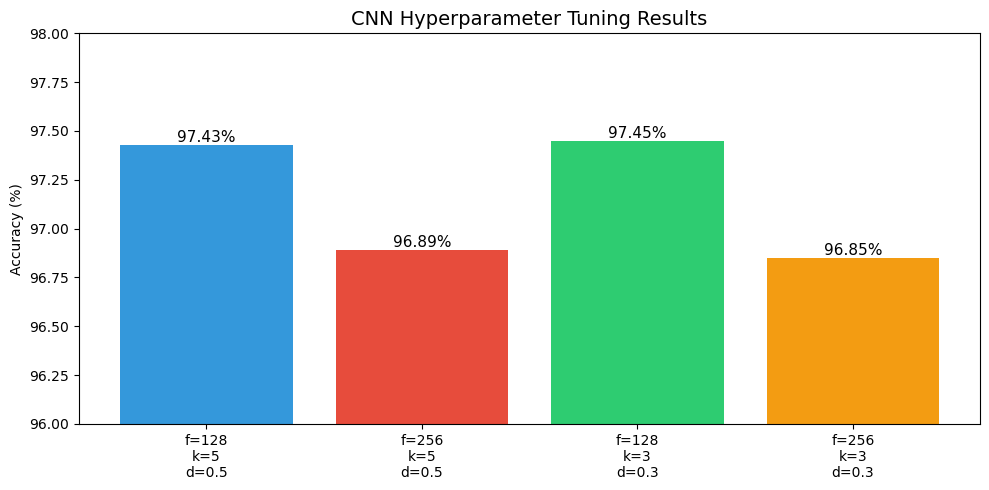

In [10]:
# Plot CNN hyperparameter tuning results
plt.figure(figsize=(10, 5))
labels = [f"f={r['filters']}\nk={r['kernel_size']}\nd={r['dropout']}" 
          for r in cnn_results]
accuracies = [r['accuracy'] for r in cnn_results]

bars = plt.bar(labels, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('CNN Hyperparameter Tuning Results', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(96, 98)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{acc}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/cnn_tuning_results.png', dpi=150)
plt.show()

### Insight - CNN Hyperparameter Tuning Results

The best result was achieved with 128 filters, kernel size 3 
and dropout rate 0.3 (97.45% accuracy). 

Smaller kernel size 3 instead of 5 worked slightly better 
because it focuses on shorter word patterns which are common 
in news headlines and short claims. Increasing filters from 
128 to 256 actually reduced accuracy, likely because the model 
became more complex and started to slightly overfit the 
training data despite dropout.

Therefore the final CNN model will use filters=128, 
kernel_size=3 and dropout=0.3.

In [13]:
# Train final best CNN model
print("Training final CNN model....")

cnn_final = build_cnn(filters=128, kernel_size=3, dropout_rate=0.3)

early_stop = EarlyStopping(monitor='val_loss', 
                            patience=2, 
                            restore_best_weights=True)

history_final = cnn_final.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Save final model
cnn_final.save('../models/cnn_final_model.keras')

final_cnn_acc = cnn_final.evaluate(X_test_pad, y_test, verbose=0)[1]
print("\nFinal CNN model trained and saved successfully")
print("Final CNN Test Accuracy:", round(final_cnn_acc * 100, 2), "%")

Training final CNN model....
Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 175s 212ms/step - accuracy: 0.9419 - loss: 0.1518 - val_accuracy: 0.9724 - val_loss: 0.0819
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 170s 210ms/step - accuracy: 0.9906 - loss: 0.0288 - val_accuracy: 0.9582 - val_loss: 0.1386
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 174s 214ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 0.9776 - val_loss: 0.0936

Final CNN model trained and saved successfully
Final CNN Test Accuracy: 96.94 %


## Model Development Summary

In this notebook I trained and tuned two models for fake news 
detection.

**Random Forest:**
- Baseline accuracy: 95.21% (100 trees)
- Tested 4 different settings (n_estimators and max_depth)
- Best result: 95.53% accuracy with 200 trees and no depth limit
- Final model trained with these best settings

**CNN:**
- Baseline accuracy: 97.15%
- Tested 4 different settings (filters, kernel size, dropout)
- Best result: 97.45% accuracy with 128 filters, kernel size 3, 
  dropout 0.3
- Final model trained with these best settings using early stopping 
  to prevent overfitting

**Initial Observation:**
CNN performed better than Random Forest on this dataset, likely 
because it can learn word order and context patterns that TF-IDF 
based Random Forest cannot capture. A full comparison with 
precision, recall, F1-score and confusion matrix will be done 
in Notebook 05.

**Note on saved models:**
Due to GitHub file size limits, the trained Random Forest model 
(185MB) and CNN model (60MB) are kept locally on my computer 
instead of being pushed to GitHub. The notebook code itself 
shows exactly how these models were trained, so they can be 
reproduced by running the notebook again.